# 03 — LangGraph 核心元件：State / Node / Edge / StateGraph

**這份要學什麼**
- State / Node / Edge：LangGraph 的三個核心元件
- reducer 決定一個欄位是「蓋掉」還是「疊加」
- `cache_policy`：同樣的輸入不用重算一次

> 這份 notebook 完全不需要 API key，也刻意先不用 LLM——先把「圖」本身的規則搞懂，之後接 LLM 只是把某個工作站換成「呼叫模型」而已。

## LangGraph 在做什麼？先想像一場接力賽

想像一場接力賽，賽道上有好幾個「工作站」，每站站著一個只做自己那件事的工人。傳來傳去的不是接力棒，而是一張「工作單」：每一站的工人看一眼工作單、做完自己的工作、在工作單上補一點資料，再把工作單傳給下一站。跑完全程，工作單上已經記滿了整個過程。

LangGraph 就是這套接力賽的程式化版本，只有四個概念：

- **State（工作單）**：整場接力賽裡大家傳來傳去的表格，規定表格上有哪些欄位
- **Node（工作站）**：一個只做自己那件事的函式，收到目前的工作單，回傳「我要補上/修改的部分」
- **Edge（走廊）**：規定「這站做完換去哪站」，下一份 notebook 會介紹「依情況走不同房間」的版本
- **StateGraph（整條賽道）**：把工作單格式＋所有工作站＋走廊接起來，`compile()` 完就變成一條真的能跑的賽道

基本流程長這樣（對照下面 `1120c45a` 那格程式碼印出的圖）：

```
START ──▶ [ node_a ] ──▶ [ node_b ] ──▶ END
           算 step_count    寫一則訊息
```

下面用實際程式碼，一一對應這四個概念。

## State：工作單的欄位，以及「補上」還是「蓋掉」的規則

State 是一個 `TypedDict`，單純描述工作單上有哪些欄位、每個欄位是什麼型別。

重點是一件事：**當有人要更新同一個欄位，新資料要「蓋掉舊的」，還是「疊加在舊的後面」？**

- 預設是「蓋掉」：工作站回傳某欄位的新值，舊值就直接被換掉
- 如果欄位標了 `Annotated[型別, reducer_fn]`，LangGraph 會呼叫 `reducer_fn(舊值, 新值)` 決定怎麼合併，而不是直接蓋掉

最常用的 reducer 是 `add_messages`：讓 `messages` 欄位變成「疊加」而不是「蓋掉」——這也是為什麼多輪對話的歷史紀錄會一直往後累加，而不是每次都被洗掉。

In [1]:
from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]  # 累加：新訊息附加到舊列表後面
    step_count: int  # 沒有 Annotated，就是覆蓋：node 回傳新值就直接取代舊值

## Node：工作站只做自己的事，只回傳「補上的部分」

`node_a` 這個工作站只回傳 `{"step_count": ...}`，完全沒提到 `messages` 欄位——這是刻意的。LangGraph 收到工作站的回傳後，會依照上面「蓋掉或疊加」的規則，自動跟目前的工作單合併。工作站不用擔心「這次沒動到的欄位會不會被清空」，只要回傳自己有更新的部分就好。

In [2]:
def node_a(state: State) -> dict:
    return {"step_count": state.get("step_count", 0) + 1}


def node_b(state: State) -> dict:
    return {"messages": [("ai", f"目前 step_count={state['step_count']}")]}

## 把工作站跟走廊組裝成賽道：`add_node`、`add_edge`、`compile()`

- `builder.add_node("node_a", node_a)`：把工作站放進賽道，給它一個名字
- `add_edge(u, v)`：蓋一條固定走廊——「跑完 u，一定接著去 v」。`START` / `END` 是兩個特殊的工作站，分別代表賽道的入口與出口
- `builder.compile()`：把整條賽道組裝完成，回傳一個真的能執行的物件

下一份 notebook 會介紹另一種走廊：站著保全、依工作單內容決定放你去哪一間房的「條件邊」。

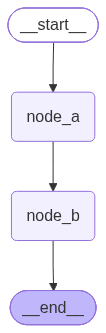

In [3]:
import sys

sys.path.insert(0, ".")
from langgraph.graph import END, START, StateGraph

from _graph_viz import show_graph

builder = StateGraph(State)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()
show_graph(graph)

上面 `show_graph()` 連得上網路會直接畫出 `__start__ -> node_a -> node_b -> __end__` 這張圖；離線的話會退回文字版 mermaid，一樣可以貼到 [mermaid.live](https://mermaid.live) 看圖。下面 `graph.invoke({...})` 就是把一張工作單交給賽道起點，讓它依序跑過每一站。

In [4]:
result = graph.invoke({"messages": [("human", "hi")], "step_count": 0})
for m in result["messages"]:
    print(type(m).__name__, m.content)
print("step_count:", result["step_count"])

HumanMessage hi
AIMessage 目前 step_count=1
step_count: 1


`compile()` 回傳的 `graph`，骨子裡跟 `01_langchain_basics.ipynb` 裡的 chain 是同一種東西——一個 `Runnable`，一樣可以 `.invoke()` / `.stream()` / `.batch()`。可以把它想成：雖然賽道內部有好幾個工作站，但整條賽道對外看起來，跟一支單一的 chain 用法完全一樣。這也是為什麼一個 `StateGraph` 可以直接接在 LCEL chain 前後，甚至被整個塞進另一張圖裡當成一個工作站來用（`09_langgraph_multi_agent.ipynb` 會用到）。

## 眼見為憑：欄位沒加 reducer 會怎樣

下面刻意做一個「沒標 `add_messages`」的版本來對照。呼叫時工作單帶著兩則人類訊息進去，`overwrite_node` 只回傳一則 AI 訊息——因為欄位沒有 reducer，回傳的值直接蓋掉舊的，結果工作單裡只剩下這一則，原本的兩則人類訊息都不見了。這跟 `add_messages` 那種「疊加」的行為完全相反。

In [5]:
class OverwriteState(TypedDict):
    messages: list  # 沒有 Annotated[..., add_messages]，回傳就是覆蓋


def overwrite_node(state: OverwriteState) -> dict:
    return {"messages": [("ai", "只剩下這一則")]}


ow_builder = StateGraph(OverwriteState)
ow_builder.add_node("overwrite", overwrite_node)
ow_builder.add_edge(START, "overwrite")
ow_builder.add_edge("overwrite", END)
ow_graph = ow_builder.compile()

ow_result = ow_graph.invoke({"messages": [("human", "第一則"), ("human", "第二則")]})
print(ow_result)  # 只會剩下 node 回傳的那一則，原本兩則被整個覆蓋

{'messages': [('ai', '只剩下這一則')]}


## 工作站的記性：`cache_policy`

如果同一張工作單，內容一模一樣又送進同一個工作站一次，工作站沒必要重做——直接把上次
算好的答案拿出來就好。這就是 `cache_policy`：幫某個 node 裝一個「小抄」，同樣的輸入
第二次進來就跳過真正執行，直接回傳快取的結果。

跟 `06` 的 checkpointer 不要搞混：checkpointer 記的是「這個對話走到哪一步」，
`cache_policy` 記的是「這個 node 對某個輸入算過什麼答案」——兩個是完全不同層次的記憶。

In [6]:
import time

from langgraph.cache.memory import InMemoryCache
from langgraph.types import CachePolicy

call_count = {"n": 0}


def slow_square(state: State) -> dict:
    call_count["n"] += 1
    time.sleep(0.1)  # 模擬很慢的計算
    return {"step_count": state["step_count"] ** 2}


cache_builder = StateGraph(State)
cache_builder.add_node("slow_square", slow_square, cache_policy=CachePolicy(ttl=60))
cache_builder.add_edge(START, "slow_square")
cache_builder.add_edge("slow_square", END)
cache_graph = cache_builder.compile(cache=InMemoryCache())

cache_graph.invoke({"messages": [], "step_count": 4})
cache_graph.invoke({"messages": [], "step_count": 4})  # 同樣的輸入，第二次應該直接吃快取
print("實際執行次數:", call_count["n"])  # 應該是 1，不是 2

實際執行次數: 1


## 小結
- 工作單（State）的每個欄位「預設蓋掉、標了 reducer 才會疊加」——這條規則後面在 memory（06）、multi-agent（09）都會反覆用到
- 工作站（Node）只回傳「補上的部分」，不用手動組出完整的工作單
- `compile()` 後的圖是標準 `Runnable`，跟 LangChain 的 chain 用同一套呼叫方式

下一份：`04_langgraph_control_flow.ipynb`，把「固定走廊」換成「站著保全的走廊」，開始表達分支跟迴圈。